<a href="https://colab.research.google.com/github/annmaria-roy/ML-LAB/blob/main/EX_4_logistic_regression_mle_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [24]:

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [25]:
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target

print(f"DATASET SHAPE: {x.shape}")
print(f"Class distribution: {np.bincount(y)}(0:Malignant,1:Benign)")

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print("processing complete")

DATASET SHAPE: (569, 30)
Class distribution: [212 357](0:Malignant,1:Benign)
processing complete


In [26]:
mle_model=LogisticRegression(penalty=None,max_iter=10000)
mle_model.fit(x_train_scaled,y_train)

map_l2_model=LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',max_iter=10000)
map_l2_model.fit(x_train_scaled,y_train)

map_l1_model=LogisticRegression(penalty='l1',C=1.0,solver='saga',max_iter=10000)
map_l1_model.fit(x_train_scaled,y_train)

weights_df=pd.DataFrame({
    'Feature':['Intercept'] + list(data.feature_names),
    'mle':np.insert(mle_model.coef_[0],0,mle_model.intercept_[0]),
    'map_l2 (Gaussian)':np.insert(map_l2_model.coef_[0],0,map_l2_model.intercept_[0]),
    'map_l1 (Laplace)':np.insert(map_l1_model.coef_[0],0,map_l1_model.intercept_[0]),
})

weights_df.head(10)

,Feature,mle,map_l2 (Gaussian),map_l1 (Laplace)
0,Intercept,-63.532600,0.445585,0.299321
1,mean radius,9.433096,-0.431904,0.000000
2,mean texture,-16.986388,-0.387326,0.000000
3,mean perimeter,40.020926,-0.393432,0.000000
4,mean area,10.890150,-0.465210,0.000000
5,mean smoothness,5.033443,-0.071667,0.000000
6,mean compactness,274.940098,0.540164,0.000000
7,mean concavity,-134.838158,-0.801458,0.000000
8,mean concave points,-266.184736,-1.119804,-2.195998
9,mean symmetry,40.996505,0.236119,0.053600


In [30]:
def evaluvate(model,x,y,name):
  preds=model.predict(x)
  probs=model.predict_proba(x)[:,1]
  return{
      'model':name,
      'accuracy':accuracy_score(y,preds),
      'precision':precision_score(y,preds),
      'recall':recall_score(y,preds),
      'f1-score':f1_score(y,preds),
      'AUC-ROC':roc_auc_score(y,probs)
  }

In [32]:
results = [
    evaluvate(mle_model, x_test_scaled, y_test, 'MLE (no regularization)'),
    evaluvate(map_l2_model, x_test_scaled, y_test, 'MAP (l2 regularization)'),
    evaluvate(map_l1_model, x_test_scaled, y_test, 'MAP (l1 regularization)')
]
pd.DataFrame(results)

,model,accuracy,precision,recall,f1-score,AUC-ROC
0,MLE (no regularization),0.938596,0.984848,0.915493,0.948905,0.981330
1,MAP (l2 regularization),0.973684,0.972222,0.985915,0.979021,0.997380
2,MAP (l1 regularization),0.964912,0.971831,0.971831,0.971831,0.996725


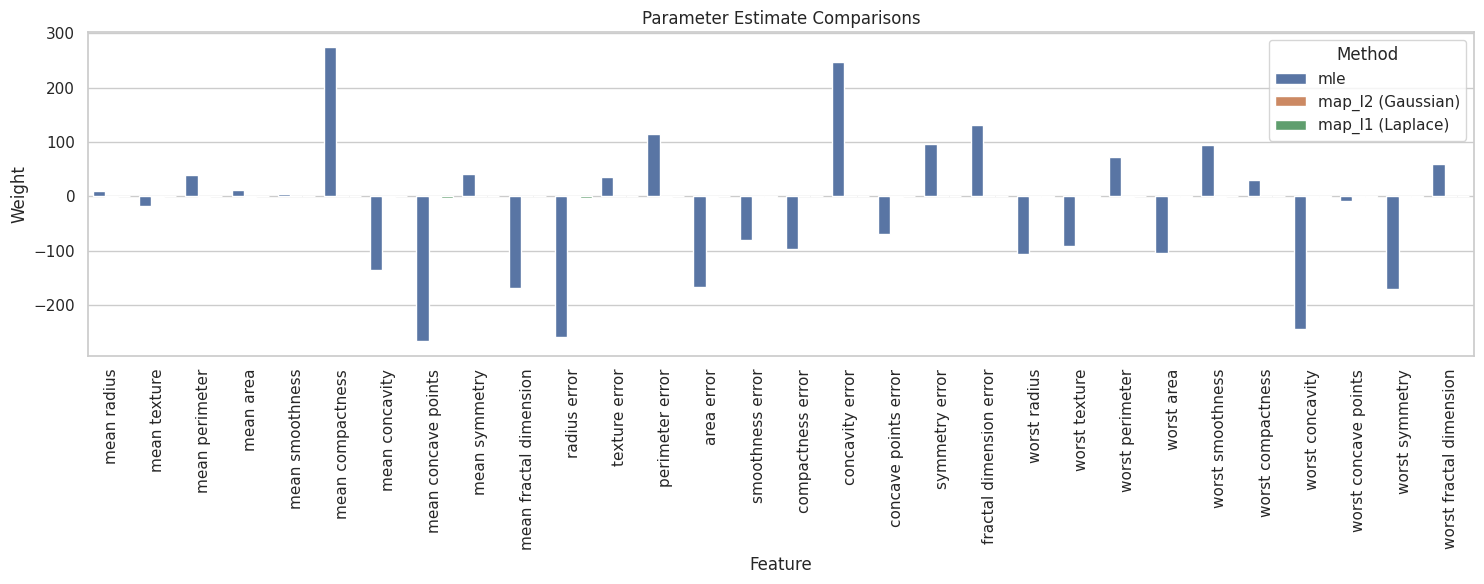

number of zero weight in l1(laplace) 15


In [34]:
plt.figure(figsize=(15, 6))

melted_w = weights_df.melt(
    id_vars='Feature',
    value_vars=['mle', 'map_l2 (Gaussian)','map_l1 (Laplace)'],
    var_name='Method',
    value_name='Weight'
)

sns.barplot(
    data=melted_w[melted_w['Feature'] != 'Intercept'],
    x='Feature',
    y='Weight',
    hue='Method',
)

plt.xticks(rotation=90)
plt.title('Parameter Estimate Comparisons')
plt.tight_layout()
plt.xlabel('Feature')
plt.ylabel('Weight')
plt.legend(title='Method')
plt.show()

print("number of zero weight in l1(laplace)",np.sum(map_l1_model.coef_==0))
